In [89]:
using DMUStudent.HW4: HW4, gw, render
using CommonRLInterface: reset!, actions, act!, observe, terminated, observations
using Plots
using Statistics: mean

In [90]:
function sarsa_lambda_episode!(Q, env; ϵ=0.1, γ=0.99, α=0.2, λ=0.99)

    start = time()

    s = observe(env)
    a = rand(actions(env))
    r = act!(env, a)
    sp = observe(env)
    hist = [s]
    N = Dict((s, a) => 0.0)

    function policy(s)
        if rand() < ϵ
            return rand(actions(env))
        end
        return argmax(a -> Q[(s,a)], actions(env))
    end
    

    while !terminated(env)
        ap = policy(sp)

        N[(s, a)] = get(N, (s, a), 0.0) + 1
        
        δ = r + γ*Q[(sp, ap)] - Q[(s, a)]

        for ((s, a), n) in N
            Q[(s, a)] += α*δ*n
            N[(s, a)] *= γ*λ
        end

        s = sp
        a = ap
        r = act!(env, a)
        sp = observe(env)
        push!(hist, sp)
    end

    N[(s, a)] = get(N, (s, a), 0.0) + 1
    δ = r - Q[(s, a)]

    for ((s, a), n) in N
        Q[(s, a)] += α*δ*n
        N[(s, a)] *= γ*λ
    end

    return (hist=hist, Q = copy(Q), time=time()-start)
end

sarsa_lambda_episode! (generic function with 2 methods)

In [91]:
function sarsa_lambda!(env; n_episodes=100, kwargs...)
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    episodes = []
    
    for i in 1:n_episodes
        reset!(env)
        push!(episodes, sarsa_lambda_episode!(Q, env;
                                              ϵ=max(0.01, 1-i/n_episodes),
                                              kwargs...))
    end
    
    return episodes
end

sarsa_lambda! (generic function with 1 method)

In [92]:
function evaluate(env, policy; n_episodes=50_000, max_steps=1000, γ=1.0)
    returns = Float64[]
    for _ in 1:n_episodes
        t = 0
        r = 0.0
        reset!(env)
        s = observe(env)
        while !terminated(env)
            a = policy(s)
            r += γ^t*act!(env, a)
            s = observe(env)
            t += 1
        end
        push!(returns, r)
    end
    return returns
end

evaluate (generic function with 1 method)

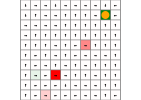

In [98]:
lambda_episodes = sarsa_lambda!(gw, n_episodes=100_000, α=0.05, λ=0.9);
episodes = Dict("SARSA-λ"=>lambda_episodes)


Q = lambda_episodes[end].Q
render(gw, policy = s -> argmax(a -> Q[(s,a)], actions(gw)))

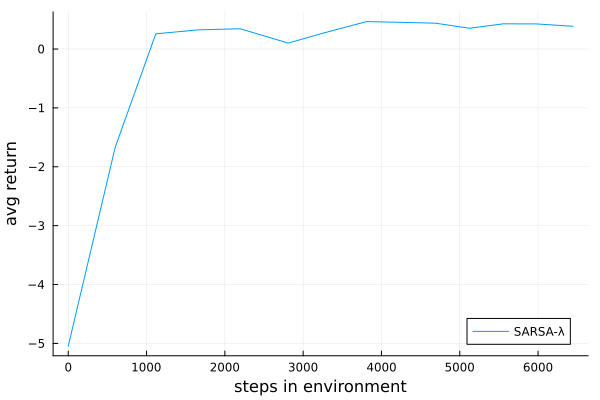

In [99]:
function learning_curve_steps(episodes,env)
	p = plot(xlabel="steps in environment", ylabel="avg return")
	n = 40
	stop = 500
	for (name, eps) in episodes
		  
	    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
	    xs = [0]
	    ys = [mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env))))]
	    for i in n:n:min(stop, length(eps))
	        newsteps = sum(length(ep.hist) for ep in eps[i-n+1:i])
	        push!(xs, last(xs) + newsteps)
	        Q = eps[i].Q
	        push!(ys, mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env)), n_episodes=1000)))
	    end    
	    plot!(p, xs, ys, label=name)
	end
	p
end
learning_curve_steps(episodes,gw)


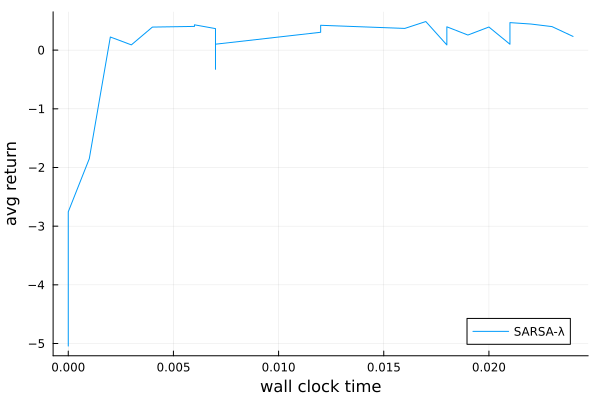

In [100]:
function learning_curve_clock(episodes,env)
	p = plot(xlabel="wall clock time", ylabel="avg return")
	n = 20
	stop = 500
	for (name,eps) in episodes
	    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
	    xs = [0.0]
	    ys = [mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env))))]
	    for i in n:n:min(stop, length(eps))
	        newtime = sum(ep.time for ep in eps[i-n+1:i])
	        push!(xs, last(xs) + newtime)
	        Q = eps[i].Q
	        push!(ys, mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env)), n_episodes=1000)))
	    end    
	    plot!(p, xs, ys, label=name)
	end
	p
end
learning_curve_clock(episodes,gw)


In [101]:


Q_final = lambda_episodes[end].Q
policy_final = s -> argmax(a -> Q_final[(s, a)], actions(gw))

returns_undiscounted = evaluate(gw, policy_final; n_episodes=1000, γ=1.0)
avg_undiscounted = mean(returns_undiscounted)

println("SARSA-Lambda Performance Check:")
println("==============================")
println("Average undiscounted cumulative reward: $avg_undiscounted")
println("Requirement: > 5")
println("Success: $(avg_undiscounted > 5 ? "YES" : "NO")")






SARSA-Lambda Performance Check:
Average undiscounted cumulative reward: 5.015974229105355
Requirement: > 5
Success: YES
